In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler



In [26]:
import pandas as pd

df = pd.read_csv("customers.csv", sep=",")
print(df.head())
print(df.columns)


  Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency
0                              1,19,Male,15000,39,10                    
1                              2,21,Male,18000,81,15                    
2                              3,20,Female,16000,6,2                    
3                            4,23,Female,20000,77,14                    
4                               5,31,Male,35000,40,7                    
Index(['Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency'], dtype='object')


In [27]:
df = df[df.columns[0]].str.split(',', expand=True)

df.columns = ['Customer_ID', 'Age', 'Gender',
              'Annual_Income', 'Spending_Score',
              'Purchase_Frequency']

print(df.head())

  Customer_ID Age  Gender Annual_Income Spending_Score Purchase_Frequency
0           1  19    Male         15000             39                 10
1           2  21    Male         18000             81                 15
2           3  20  Female         16000              6                  2
3           4  23  Female         20000             77                 14
4           5  31    Male         35000             40                  7


In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print(df.head())

  Customer_ID Age  Gender Annual_Income Spending_Score Purchase_Frequency
0           1  19       1         15000             39                 10
1           2  21       1         18000             81                 15
2           3  20       0         16000              6                  2
3           4  23       0         20000             77                 14
4           5  31       1         35000             40                  7


In [30]:
X = df[['Age', 'Annual_Income', 'Spending_Score']]

print("\nSelected Features:")
print(X.head())



Selected Features:
  Age Annual_Income Spending_Score
0  19         15000             39
1  21         18000             81
2  20         16000              6
3  23         20000             77
4  31         35000             40


In [35]:
print(df.head())
print(df.columns)
print(type(df))

  Customer_ID Age  Gender Annual_Income Spending_Score Purchase_Frequency
0           1  19       1         15000             39                 10
1           2  21       1         18000             81                 15
2           3  20       0         16000              6                  2
3           4  23       0         20000             77                 14
4           5  31       1         35000             40                  7
Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Spending_Score',
       'Purchase_Frequency'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>


In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)


[[-1.07359218 -1.75588652 -0.36113726]
 [-0.92612073 -1.62765722  0.94193532]
 [-0.99985645 -1.71314342 -1.38497999]
 [-0.77864927 -1.54217103  0.81783317]
 [-0.18876346 -0.90102454 -0.33011172]
 [-0.852385   -1.32845553  0.78680763]
 [ 0.10617945 -0.68730904 -1.38497999]
 [-0.77864927 -0.47359354  1.34526731]
 [ 2.24451552 -0.25987804 -1.47805661]
 [-0.26249919 -0.17439185  0.66270548]
 [ 2.4657227  -0.08890565 -1.13677569]
 [ 0.10617945  0.08206675  1.50039499]
 [ 1.80210116  0.16755295 -1.10575016]
 [-0.70491355  0.25303915  0.81783317]
 [ 0.2536509   0.38126845 -1.16780123]
 [-0.852385    0.46675465  0.87988424]
 [ 0.10617945  0.59498394 -0.48523941]
 [-0.99985645  0.68047014  0.47655226]
 [ 1.3596868   0.80869944 -0.67139263]
 [ 0.10617945  0.93692874  1.46936945]
 [ 0.10617945  1.02241494 -0.48523941]
 [-0.63117782  1.10790114  0.69373102]
 [ 0.91727244  1.23613043 -1.41600553]
 [-0.18876346  1.36435973  0.97296086]
 [-0.33623491  1.44984593  0.04219473]]


In [40]:
# Choose optimal clusters (example: 5)
k = 5

kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    random_state=42
)

# Predict cluster labels
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = y_kmeans

print("\nClustered Data:")
print(df.head())



Clustered Data:
  Customer_ID Age  Gender Annual_Income Spending_Score Purchase_Frequency  \
0           1  19       1         15000             39                 10   
1           2  21       1         18000             81                 15   
2           3  20       0         16000              6                  2   
3           4  23       0         20000             77                 14   
4           5  31       1         35000             40                  7   

   Cluster  
0        4  
1        0  
2        4  
3        0  
4        4  


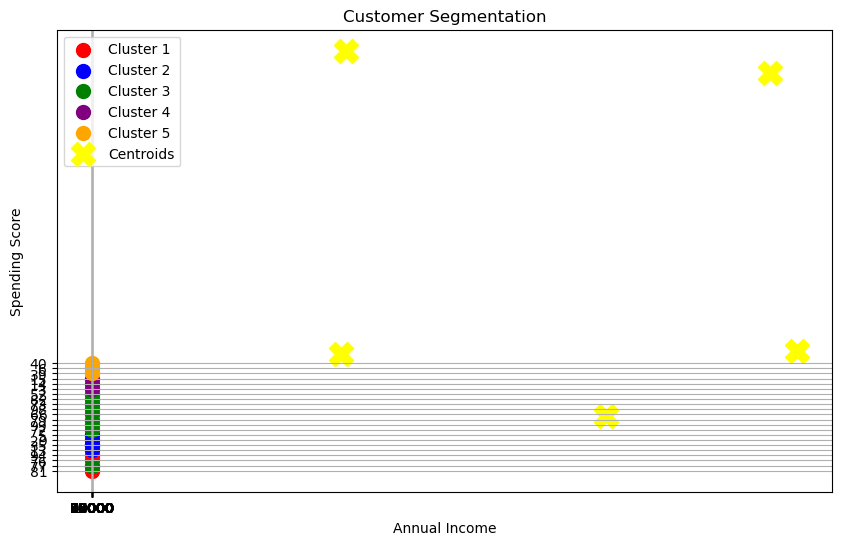

In [41]:
plt.figure(figsize=(10,6))

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(k):
    plt.scatter(
        X.iloc[y_kmeans == i, 1],   # Annual Income
        X.iloc[y_kmeans == i, 2],   # Spending Score
        s=100,
        c=colors[i],
        label=f'Cluster {i+1}'
    )

# Plot Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,1],
    centroids[:,2],
    s=300,
    c='yellow',
    label='Centroids',
    marker='X'
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
print("\nCluster Analysis:")

for i in range(k):
    print(f"\nCustomers in Cluster {i+1}:")
    print(df[df['Cluster'] == i].head())


Cluster Analysis:

Customers in Cluster 1:
  Customer_ID Age  Gender Annual_Income Spending_Score Purchase_Frequency  \
1           2  21       1         18000             81                 15   
3           4  23       0         20000             77                 14   
5           6  22       0         25000             76                 13   
7           8  23       0         45000             94                 18   

   Cluster  
1        0  
3        0  
5        0  
7        0  

Customers in Cluster 2:
   Customer_ID Age  Gender Annual_Income Spending_Score Purchase_Frequency  \
14          15  37       1         65000             13                  5   
16          17  35       1         70000             35                  8   
18          19  52       1         75000             29                  6   
20          21  35       1         80000             35                  9   
22          23  46       1         85000              5                  2   

    Cluster

In [43]:
df.to_csv("clustered_customers.csv", index=False)

print("\nClustered customer data saved successfully!")


Clustered customer data saved successfully!
